In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 20250915-laporan-keuangan-publikasi-bulanan-agustus-2025-ind.pdf to 20250915-laporan-keuangan-publikasi-bulanan-agustus-2025-ind.pdf
Saving 20251114-laporan-keuangan-publikasi-bulanan-oktober-2025-ind.pdf to 20251114-laporan-keuangan-publikasi-bulanan-oktober-2025-ind.pdf
Saving 20251215-laporan-keuangan-publikasi-bulanan-november-2025-ID.pdf to 20251215-laporan-keuangan-publikasi-bulanan-november-2025-ID.pdf
Saving 20260213-Laporan-Keuangan-Publikasi-Bulanan-Januari-2026-ID.pdf to 20260213-Laporan-Keuangan-Publikasi-Bulanan-Januari-2026-ID.pdf
Saving 20260313-laporan-keuangan-publikasi-bulanan-februari-2026-ind.pdf to 20260313-laporan-keuangan-publikasi-bulanan-februari-2026-ind.pdf


In [ ]:
import os

pdf_files = [file for file in os.listdir() if file.endswith(".pdf")]
pdf_files

['20250915-laporan-keuangan-publikasi-bulanan-agustus-2025-ind.pdf',
 '20251215-laporan-keuangan-publikasi-bulanan-november-2025-ID.pdf',
 '20251114-laporan-keuangan-publikasi-bulanan-oktober-2025-ind.pdf',
 '20260313-laporan-keuangan-publikasi-bulanan-februari-2026-ind.pdf',
 '20260213-Laporan-Keuangan-Publikasi-Bulanan-Januari-2026-ID.pdf']

In [ ]:
!pip install pdfplumber pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.0 MB/s eta 0:00:00


In [ ]:
import pdfplumber

def extract_text_from_pdf(file):
    text = ""
    with pdfplumber.open(file) as pdf:
        for page in pdf.pages:
            if page.extract_text():
                text += page.extract_text() + "\n"
    return text

# test 1 file dulu
text = extract_text_from_pdf(pdf_files[0])
print(text[:1000])

PT BANK CENTRAL ASIA Tbk
LAPORAN POSISI KEUANGAN (NERACA)
Pada tanggal 31 Agustus 2025
(Dalam jutaan Rupiah)
INDIVIDUAL
No. POS - POS Tidak Diaudit
31 Agt 2025
ASET
1. Kas 16.440.985
2. Penempatan pada Bank Indonesia 56.832.717
3. Penempatan pada bank lain 16.169.026
4. Tagihan spot dan derivatif/forward 121.571
5. Surat berharga yang dimiliki 4 01.055.641
6. Surat berharga yang dijual dengan janji dibeli kembali (repo) 4.006.930
7. Tagihan atas surat berharga yang dibeli dengan janji
dijual kembali (reverse repo) 8.390.110
8. Tagihan akseptasi 10.669.659
9. Kredit dan pembiayaan yang diberikan 9 20.872.163
10. Pembiayaan syariah -
11. Penyertaan Modal 10.309.646
12. Aset keuangan lainnya 15.213.932
13. Cadangan kerugian penurunan nilai aset keuangan -/- (33.005.915)
a. Surat berharga yang dimiliki (423.622)
b. Kredit yang diberikan dan pembiayaan syariah (32.237.035)
c. Lainnya (345.258)
14. Aset tidak berwujud 1.280.314
Akumulasi amortisasi aset tidak berwujud -/- (775.170)
15. Aset 

In [ ]:
import re

def extract_financial_data(text):
    data = {}

    # Laba Bersih
    laba = re.search(r"LABA.*BERSIH.*?([\d\.\(\)]+)", text)
    if laba:
        data["laba_bersih"] = laba.group(1)

    # Pendapatan Bunga
    pendapatan = re.search(r"Pendapatan Bunga\s+([\d\.]+)", text)
    if pendapatan:
        data["pendapatan_bunga"] = pendapatan.group(1)

    # Total Aset
    aset = re.search(r"TOTAL ASET\s+([\d\.]+)", text)
    if aset:
        data["total_aset"] = aset.group(1)

    return data

In [ ]:
all_data = []

for file in pdf_files:
    text = extract_text_from_pdf(file)
    data = extract_financial_data(text)
    data["file"] = file  # identitas bulan
    all_data.append(data)

all_data

[{'laba_bersih': '39.058.614',
  'pendapatan_bunga': '61.382.110',
  'total_aset': '1',
  'file': '20250915-laporan-keuangan-publikasi-bulanan-agustus-2025-ind.pdf'},
 {'laba_bersih': '52.666.603',
  'pendapatan_bunga': '84.307.488',
  'total_aset': '1',
  'file': '20251215-laporan-keuangan-publikasi-bulanan-november-2025-ID.pdf'},
 {'laba_bersih': '48.256.793',
  'pendapatan_bunga': '76.761.213',
  'total_aset': '1',
  'file': '20251114-laporan-keuangan-publikasi-bulanan-oktober-2025-ind.pdf'},
 {'laba_bersih': '9.228.168',
  'pendapatan_bunga': '14.985.883',
  'total_aset': '1',
  'file': '20260313-laporan-keuangan-publikasi-bulanan-februari-2026-ind.pdf'},
 {'laba_bersih': '4.998.701',
  'pendapatan_bunga': '7.742.197',
  'total_aset': '1',
  'file': '20260213-Laporan-Keuangan-Publikasi-Bulanan-Januari-2026-ID.pdf'}]

In [ ]:
import pandas as pd

df = pd.DataFrame(all_data)
df

,laba_bersih,pendapatan_bunga,total_aset,file
0,39.058.614,61.382.110,1,20250915-laporan-keuangan-publikasi-bulanan-ag...
1,52.666.603,84.307.488,1,20251215-laporan-keuangan-publikasi-bulanan-no...
2,48.256.793,76.761.213,1,20251114-laporan-keuangan-publikasi-bulanan-ok...
3,9.228.168,14.985.883,1,20260313-laporan-keuangan-publikasi-bulanan-fe...
4,4.998.701,7.742.197,1,20260213-Laporan-Keuangan-Publikasi-Bulanan-Ja...


In [ ]:
def clean_number(x):
    if pd.isna(x):
        return None
    return int(x.replace(".", "").replace("(", "-").replace(")", ""))

for col in ["laba_bersih", "pendapatan_bunga", "total_aset"]:
    df[col] = df[col].apply(clean_number)

df

,laba_bersih,pendapatan_bunga,total_aset,file
0,39058614,61382110,1,20250915-laporan-keuangan-publikasi-bulanan-ag...
1,52666603,84307488,1,20251215-laporan-keuangan-publikasi-bulanan-no...
2,48256793,76761213,1,20251114-laporan-keuangan-publikasi-bulanan-ok...
3,9228168,14985883,1,20260313-laporan-keuangan-publikasi-bulanan-fe...
4,4998701,7742197,1,20260213-Laporan-Keuangan-Publikasi-Bulanan-Ja...


In [ ]:
import re

def extract_date_from_filename(filename):
    match = re.search(r"(\d{8})", filename)

    if match:
        date_str = match.group(1)
        tahun = date_str[:4]
        bulan = date_str[4:6]
        return tahun, bulan
    return None, None

def convert_bulan(bulan):
    bulan_map = {
        "01": "Januari", "02": "Februari", "03": "Maret",
        "04": "April", "05": "Mei", "06": "Juni",
        "07": "Juli", "08": "Agustus", "09": "September",
        "10": "Oktober", "11": "November", "12": "Desember"
    }
    return bulan_map.get(bulan, "Tidak diketahui")

# Terapkan ke dataframe
df["tahun"], df["bulan_angka"] = zip(*df["file"].apply(extract_date_from_filename))
df["bulan_nama"] = df["bulan_angka"].apply(convert_bulan)

# Gabungkan
df["periode"] = df["bulan_nama"] + " " + df["tahun"]

In [ ]:
import pandas as pd

# 1. Buat kolom tanggal (untuk sorting yang benar)
df["tanggal"] = pd.to_datetime(df["tahun"] + "-" + df["bulan_angka"] + "-01")

# 2. Urutkan berdasarkan tanggal
df = df.sort_values("tanggal").reset_index(drop=True)

# 3. Hitung growth
df["growth_laba_%"] = df["laba_bersih"].pct_change() * 100
df["growth_aset_%"] = df["total_aset"].pct_change() * 100

# 4. Handle NaN (bulan pertama)
df["growth_laba_%"] = df["growth_laba_%"].fillna(0)
df["growth_aset_%"] = df["growth_aset_%"].fillna(0)

# 5. Hapus kolom yang tidak diperlukan
df = df.drop(columns=["bulan", "file"], errors='ignore')

# 6. Rapikan urutan kolom
df = df[[
    "periode",
    "tahun",
    "bulan_nama",
    "laba_bersih",
    "total_aset",
    "growth_laba_%",
    "growth_aset_%",
    "tanggal"
]]

# 7. Format angka
df["laba_bersih"] = df["laba_bersih"].astype(int)
df["total_aset"] = df["total_aset"].astype(int)

df["growth_laba_%"] = df["growth_laba_%"].round(2)
df["growth_aset_%"] = df["growth_aset_%"].round(2)

# 8. Tampilkan hasil
df

,periode,tahun,bulan_nama,laba_bersih,total_aset,growth_laba_%,growth_aset_%,tanggal
0,September 2025,2025,September,39058614,1,0.00,0.0,2025-09-01
1,November 2025,2025,November,48256793,1,23.55,0.0,2025-11-01
2,Desember 2025,2025,Desember,52666603,1,9.14,0.0,2025-12-01
3,Februari 2026,2026,Februari,4998701,1,-90.51,0.0,2026-02-01
4,Maret 2026,2026,Maret,9228168,1,84.61,0.0,2026-03-01


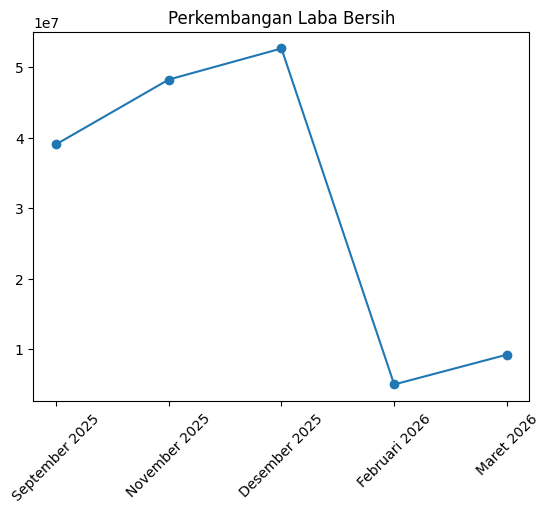

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df["periode"], df["laba_bersih"], marker='o')
plt.title("Perkembangan Laba Bersih")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def generate_summary(df):
    latest = df.iloc[-1]

    return f"""
    Pada bulan {latest['periode']}, perusahaan mencatat laba sebesar {latest['laba_bersih']}.
    Terjadi pertumbuhan laba sebesar {latest['growth_laba_%']:.2f}% dibanding bulan sebelumnya.
    Total aset mencapai {latest['total_aset']}.
    """

print(generate_summary(df))


    Pada bulan Maret 2026, perusahaan mencatat laba sebesar 9228168.
    Terjadi pertumbuhan laba sebesar 84.61% dibanding bulan sebelumnya.
    Total aset mencapai 1.
    
